# Task 3: Heart Disease Prediction

**Objective:** Build a model to predict whether a person is at risk of heart disease based on their health data.

**Dataset:** Heart Disease UCI Dataset (available on Kaggle).

**Approach:**
1. Load and clean the dataset (handle missing values).
2. Perform Exploratory Data Analysis (EDA).
3. Train classification models (Logistic Regression and Decision Tree).
4. Evaluate using accuracy, ROC-AUC, and confusion matrix.
5. Identify and visualize the most important features driving predictions.

## 1. Getting the Dataset

Download the **Heart Disease UCI Dataset** from Kaggle, for example:
`https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data` (or any equivalent UCI heart disease CSV).

Place the CSV file in the same folder as this notebook and update `DATA_PATH` below if your filename is different.

**Typical columns in this dataset:**
- `age`, `sex`, `cp` (chest pain type), `trestbps` (resting blood pressure), `chol` (cholesterol),
  `fbs` (fasting blood sugar), `restecg` (resting ECG), `thalach` (max heart rate),
  `exang` (exercise-induced angina), `oldpeak`, `slope`, `ca`, `thal`, and
  `target` (0 = no disease, 1 = disease) — column names can vary slightly between Kaggle versions.

## 2. Import Libraries

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay
)

sns.set_style("whitegrid")

## 3. Load the Dataset

In [2]:
DATA_PATH = "/home/umarfarooq/SQL PlayGround/DHC Internship/heart_disease_uci.csv"  # update this path to match your downloaded file

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 4. Initial Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 5. Handle Missing Values

We check for missing or invalid entries. Some versions of this dataset use `?` as a placeholder for missing values instead of `NaN`, so we account for that too.

In [5]:
# Replace common missing-value placeholders with NaN
df = df.replace('?', np.nan)

# Convert all columns to numeric where possible (handles any '?' -> NaN conversions)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


/tmp/ipykernel_20663/2713527263.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [6]:
# Drop duplicate rows if any
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df = df.drop_duplicates()

# Fill missing numeric values with median (robust to outliers), categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values remain")

Duplicate rows found: 0


Missing values after cleaning:
0 total missing values remain


**Observation:** Most public versions of this dataset are already fairly clean with only a few missing values (often in the `ca` and `thal` columns of the original UCI version). Filling numeric gaps with the median avoids letting outliers skew the imputed values.

## 6. Target Variable Distribution

It's important to check class balance before modeling, since an imbalanced target can mislead simple accuracy metrics.

/tmp/ipykernel_20663/3140591133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='deep')


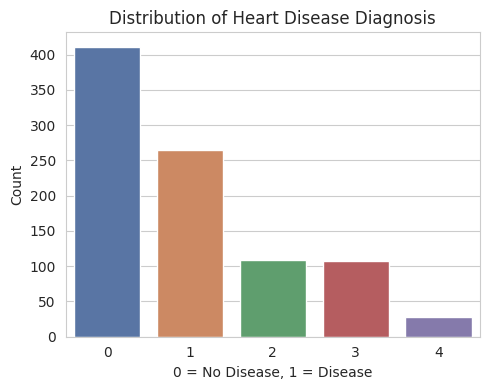

num
0    0.446739
1    0.288043
2    0.118478
3    0.116304
4    0.030435
Name: proportion, dtype: float64


In [7]:
target_col = 'num'

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x=target_col, palette='deep')
plt.title('Distribution of Heart Disease Diagnosis')
plt.xlabel('0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df[target_col].value_counts(normalize=True))

**What this shows:** Note whether the classes are roughly balanced (close to 50/50) or skewed. The original UCI heart disease dataset is fairly balanced, which means plain accuracy is a reasonably trustworthy metric here — but we still check ROC-AUC and the confusion matrix below in case that's not true for your specific file.

## 7. EDA — Age Distribution by Diagnosis

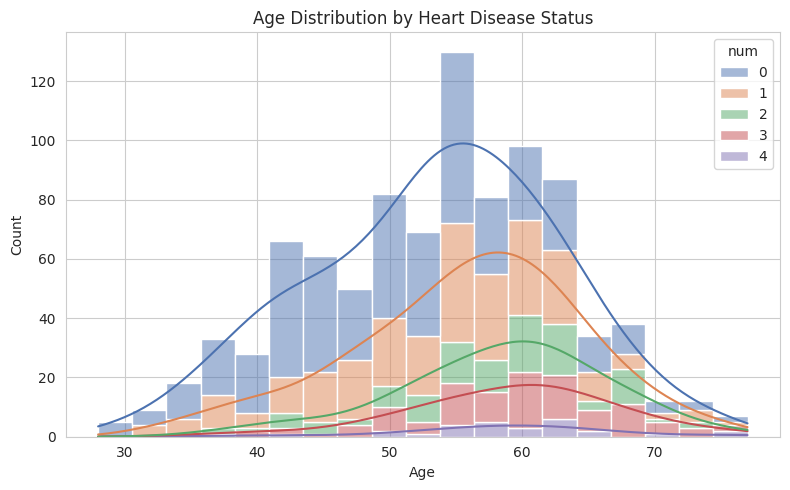

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue=target_col, kde=True, multiple='stack', palette='deep')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

**What this shows:** Heart disease cases tend to cluster in the middle-to-older age ranges, which matches medical expectations — risk generally increases with age. If the two distributions overlap heavily, it tells us age alone isn't a strong standalone predictor and the model will need to combine it with other features.

## 8. EDA — Correlation Heatmap

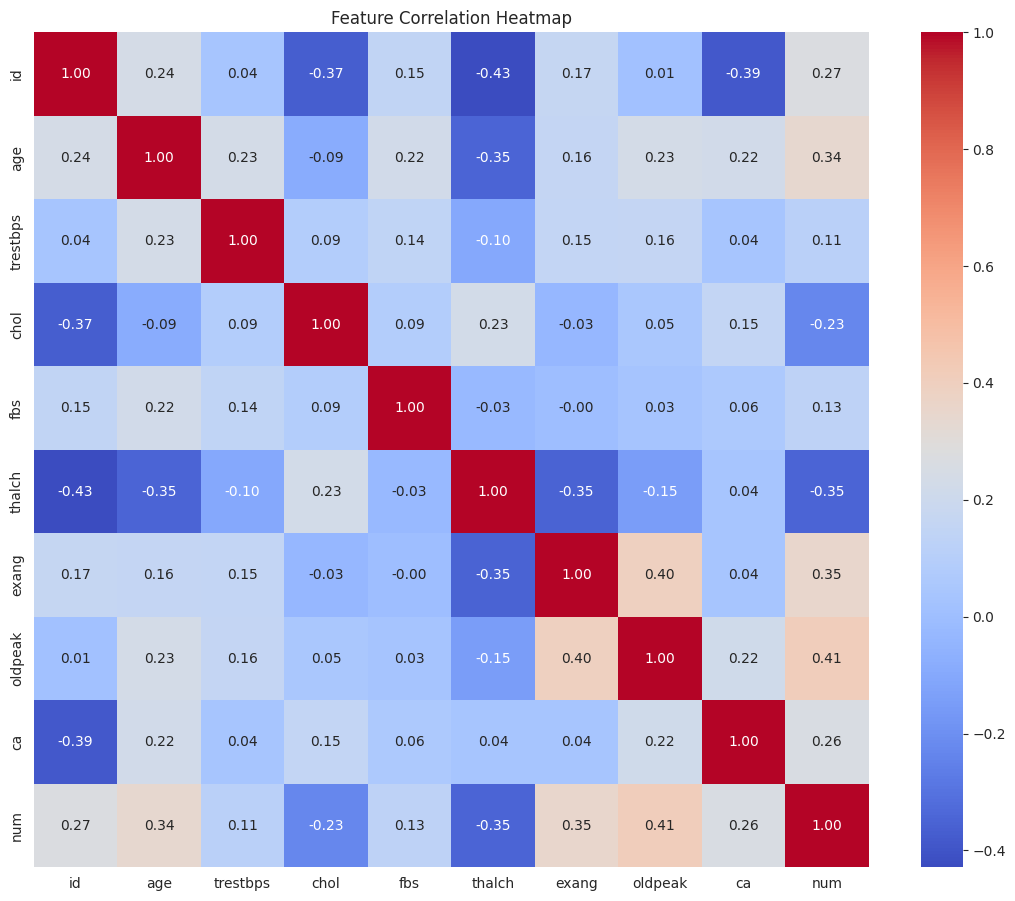

In [9]:
plt.figure(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

**What this shows:** The target variable (num), which indicates the presence or severity of heart disease, shares its strongest positive correlations with `oldpeak` (0.41), `exang` (0.35), and `age` (0.34). Conversely, `thalach` (maximum heart rate) has a noticeable negative correlation (-0.35) with num, meaning that lower maximum heart rates are generally associated with a higher likelihood of heart disease.

## 9. EDA — Key Features by Diagnosis

/tmp/ipykernel_20663/1596831677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feature, ax=ax, palette='deep')
/tmp/ipykernel_20663/1596831677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feature, ax=ax, palette='deep')
/tmp/ipykernel_20663/1596831677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=feature, ax=ax, palette='deep')
/tmp/ipykernel_20663/1596831677.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

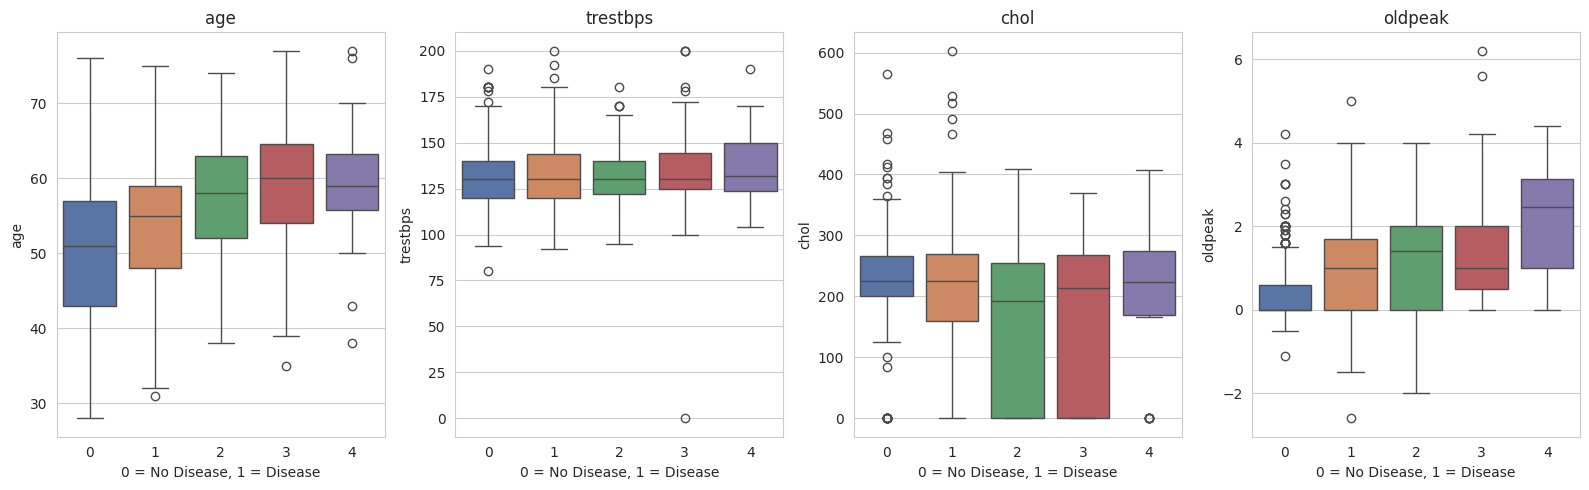

In [10]:
key_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(1, len(key_features), figsize=(4*len(key_features), 5))
for ax, feature in zip(axes, key_features):
    sns.boxplot(data=df, x=target_col, y=feature, ax=ax, palette='deep')
    ax.set_title(feature)
    ax.set_xlabel('0 = No Disease, 1 = Disease')

plt.tight_layout()
plt.show()

**What this shows:**

The boxplots visualize the distribution of key continuous medical features across different stages of heart disease severity (`num` columns from 0 to 4, where 0 means No Disease and 1–4 represent increasing severity stages):

* **Age vs. Disease Severity**: There is a clear upward trend showing that older patients are more likely to have higher disease severity stages. The median age steadily increases from around 50 (for No Disease) up to 60+ for advanced stages.
* **Resting Blood Pressure (`trestbps`)**: The median resting blood pressure remains relatively stable across all stages (around 130 mmHg), but there are prominent high-value outliers reaching up to 200 mmHg across multiple classes.
* **Cholesterol (`chol`)**: Serum cholesterol distributions show heavy overlapping across classes, but the "No Disease" (0) and stage 1 groups show a higher density of extreme outliers (some exceeding 500-600 mg/dl).
* **ST Depression (`oldpeak`)**: This feature shows a strong, visible upward trend. As the heart disease severity stage increases from 0 to 4, the median `oldpeak` value rises significantly, indicating that higher ST depression is a strong indicator of advanced heart disease.


## 10. Prepare Data for Modeling

We separate features and target, then split into train/test sets. We also scale features for Logistic Regression (Decision Trees don't require scaling, but it doesn't hurt to keep a scaled and unscaled version available).

In [11]:
X = df.drop(columns=[target_col])
y = df[target_col]

if 'id' in X.columns:
    X = X.drop(columns=['id'])
    
# If target has more than 2 classes (some UCI versions use 0-4), convert to binary: 0 = no disease, 1+ = disease
if y.nunique() > 2:
    y = (y > 0).astype(int)

# 3. Convert string columns into numeric format
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scale the numerical data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_scaled.shape, " Test size:", X_test_scaled.shape)

Train size: (736, 21)  Test size: (184, 21)


## 11. Model 1 — Logistic Regression

In [12]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

log_acc = accuracy_score(y_test, log_preds)
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.8370

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



## 12. Model 2 — Decision Tree Classifier

In [13]:
tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)  # tree-based models don't need scaling

tree_preds = tree_model.predict(X_test)
tree_probs = tree_model.predict_proba(X_test)[:, 1]

tree_acc = accuracy_score(y_test, tree_preds)
print(f"Decision Tree Accuracy: {tree_acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, tree_preds))

Decision Tree Accuracy: 0.8043

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.78        82
           1       0.81      0.84      0.83       102

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.80      0.80      0.80       184



## 13. Confusion Matrices

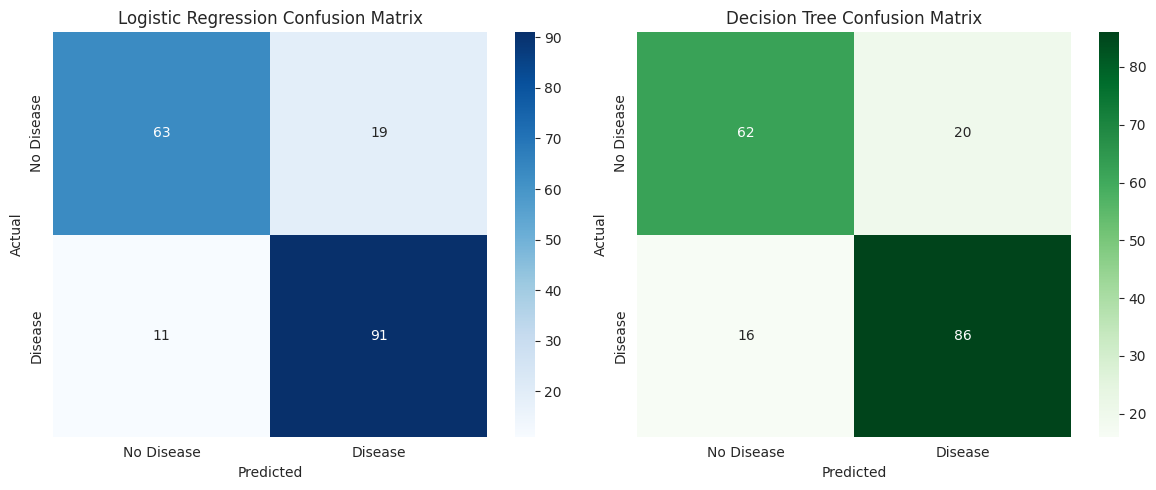

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, log_preds)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_tree = confusion_matrix(y_test, tree_preds)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**How to read this:** 
1. Top-Left (63) – True Negatives (TN): Healthy people whom the model correctly predicted as No Disease.
2. Bottom-Right (91) – True Positives (TP): Patients with heart disease whom the model correctly predicted as Disease.
3. Top-Right (19) – False Positives (FP): Healthy people whom the model incorrectly flagged as having Disease (Type I Error).
4. Bottom-Left (11) – False Negatives (FN): Sick patients whom the model missed and incorrectly predicted as No Disease (Type II Error).

## 14. ROC Curve and AUC Comparison

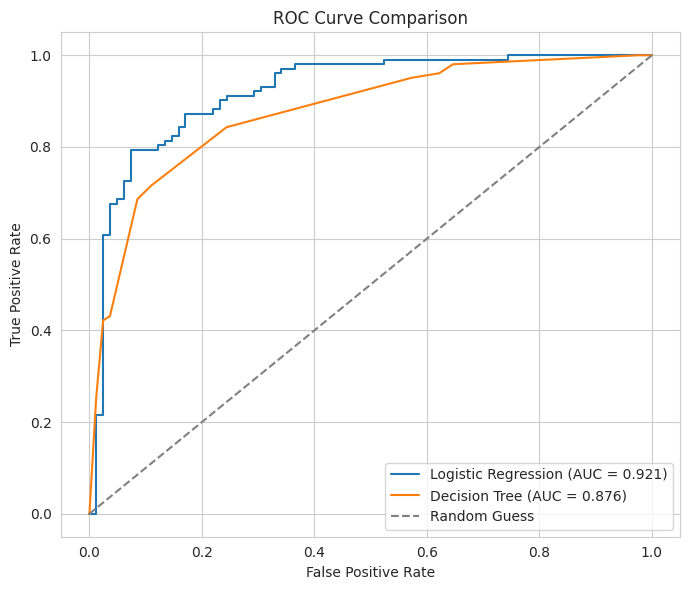

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
auc_log = roc_auc_score(y_test, log_probs)
ax.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')

fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_probs)
auc_tree = roc_auc_score(y_test, tree_probs)
ax.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {auc_tree:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

**What this shows:** 
1. **Model Comparison:** This chart compares the classification performance of Logistic Regression and Decision Tree models using an ROC curve.
2. **Understanding Axes:** The Y-axis shows the True Positive Rate (correctly caught cases), while the X-axis tracks the False Positive Rate (false alarms).
3. **The Winner:** Logistic Regression wins with a higher AUC score of 0.921 (vs. 0.876), meaning its curve hugs the top-left corner closer and separates the classes more effectively.

## 15. Feature Importance — Logistic Regression Coefficients

/tmp/ipykernel_20663/1411209002.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=log_importance, x='Coefficient', y='Feature', palette='coolwarm')


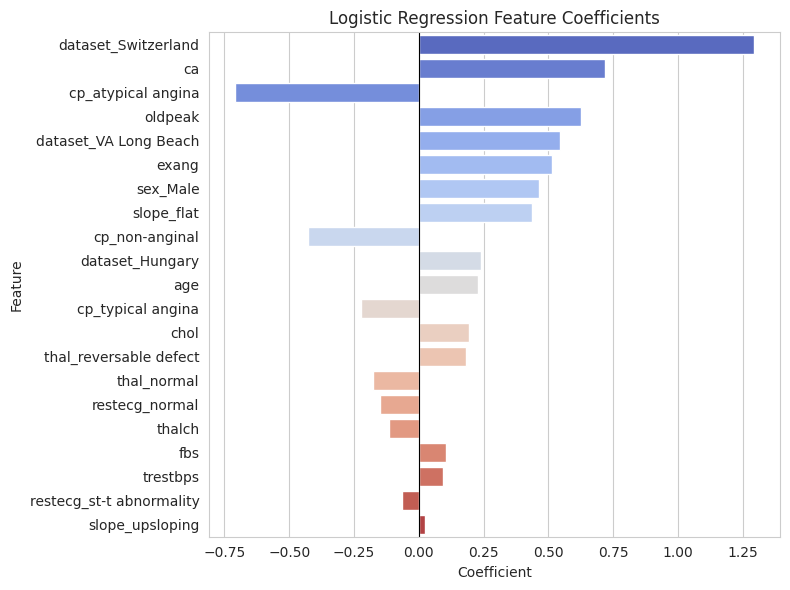

,Feature,Coefficient
10,dataset_Switzerland,1.293912
7,ca,0.716865
12,cp_atypical angina,-0.708645
6,oldpeak,0.625548
11,dataset_VA Long Beach,0.545429
5,exang,0.515885
8,sex_Male,0.463632
17,slope_flat,0.438614
13,cp_non-anginal,-0.425603
9,dataset_Hungary,0.240902


In [20]:
log_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=log_importance, x='Coefficient', y='Feature', palette='coolwarm')
plt.title('Logistic Regression Feature Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

log_importance

**What this shows:** 
1. ``Feature Impact:`` This chart shows the coefficients (weights) of your Logistic Regression model, indicating how strongly each feature drives the prediction toward "Disease" or "No Disease".
2. ``Positive Drivers:`` Features with positive coefficients (bars pointing right like dataset_Switzerland at 1.29 and ca at 0.72) increase the likelihood of a heart disease prediction as their values rise.
3. ``Protective/Negative Drivers:`` Features with negative coefficients (bars pointing left like cp_atypical angina at -0.71) decrease the likelihood of a heart disease prediction when they are present.

## 16. Feature Importance — Decision Tree

/tmp/ipykernel_20663/1070616859.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tree_importance, x='Importance', y='Feature', palette='viridis')


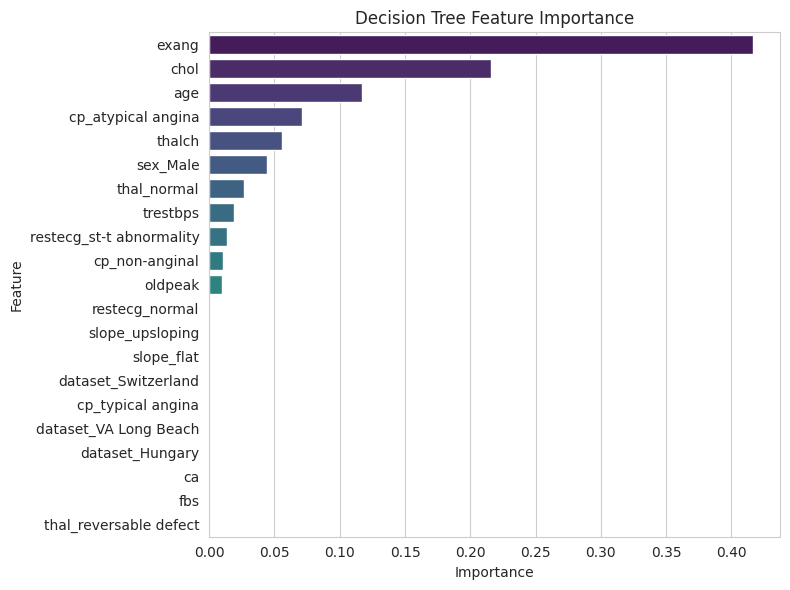

,Feature,Importance
5,exang,0.416360
2,chol,0.215962
0,age,0.116913
12,cp_atypical angina,0.071069
4,thalch,0.055867
8,sex_Male,0.044296
19,thal_normal,0.026386
1,trestbps,0.018891
16,restecg_st-t abnormality,0.013468
13,cp_non-anginal,0.010803


In [17]:
tree_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': tree_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=tree_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

tree_importance

## 17. Visualize the Decision Tree Structure

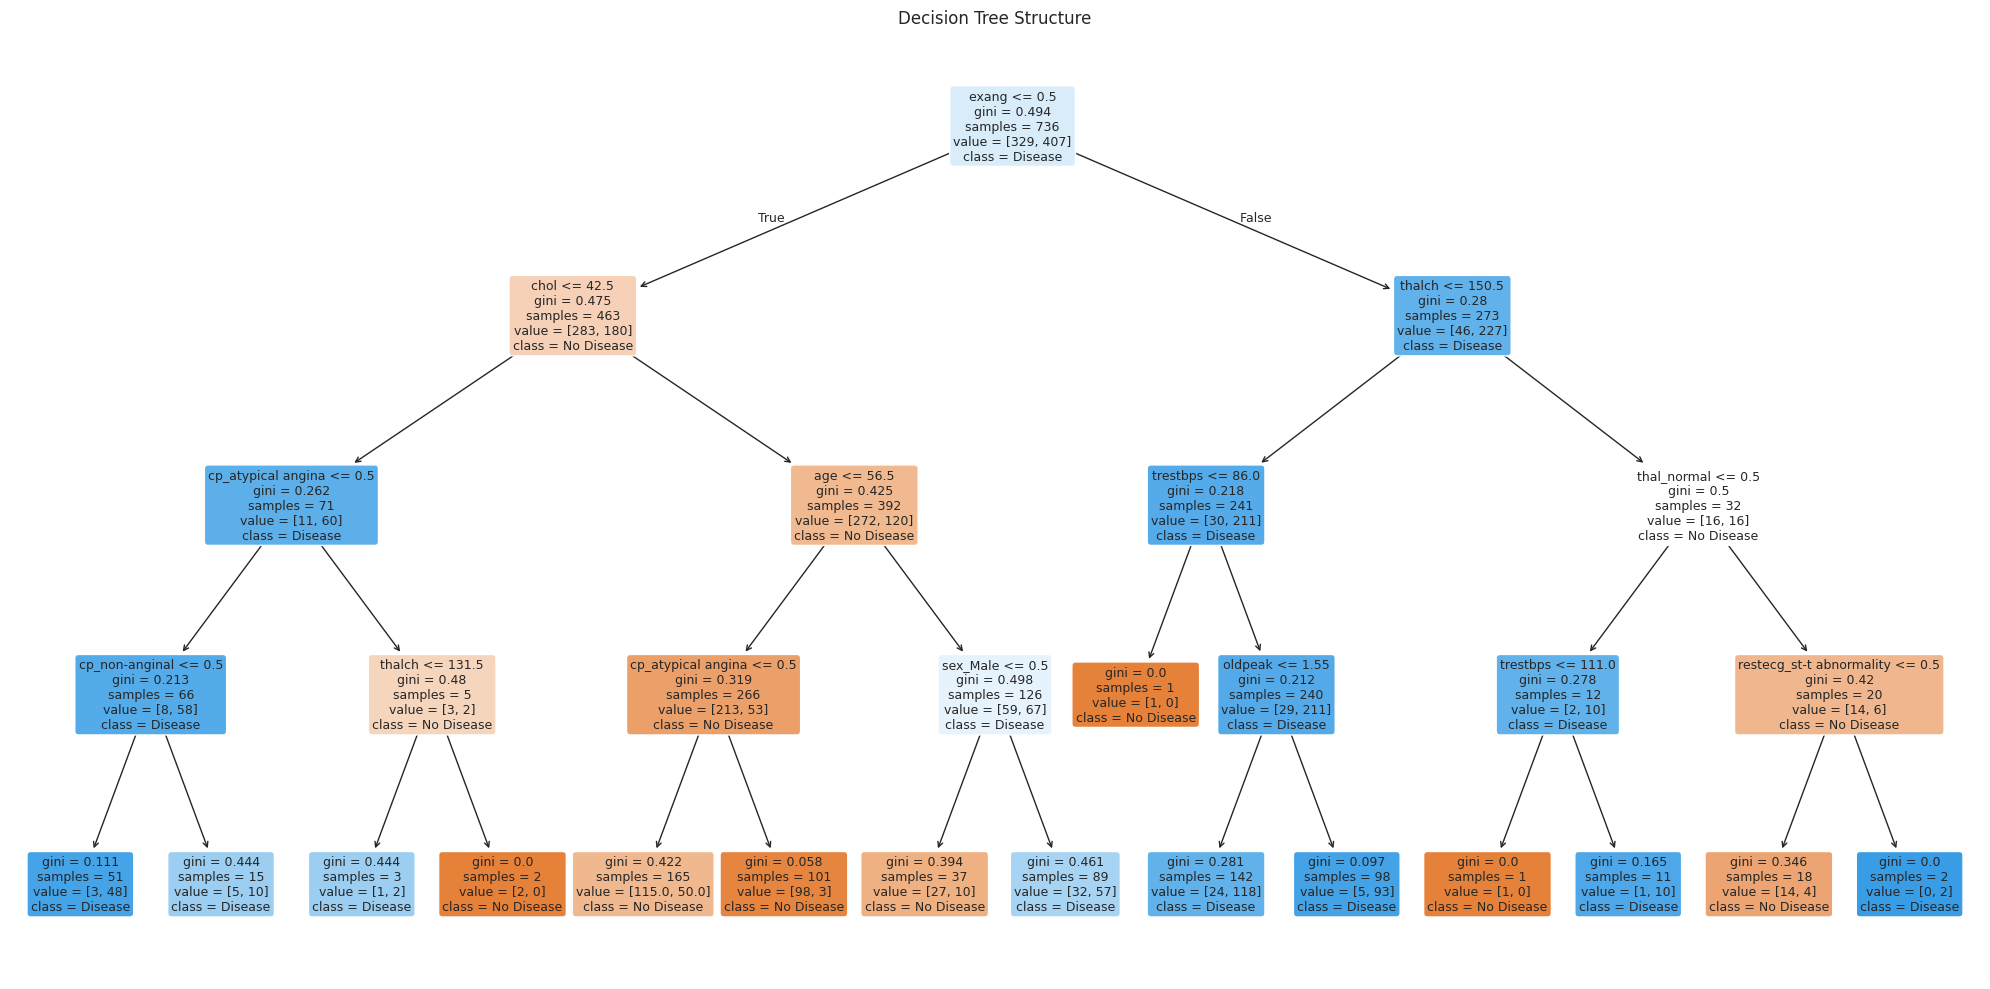

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X_encoded.columns, class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree Structure')
plt.tight_layout()
plt.show()

**What this shows:**  
### Decision Tree Architecture and Decision Rules

* **Tree Segmentation Logic**: This flowchart visualizes the internal decision-making process of your Decision Tree, showing exactly how patients are split into subgroups based on specific clinical thresholds.
* **Root & Top Splits**: The root decision node at the very top splits patients on `exang <= 0.5` (exercise-induced angina), identifying it as the single most critical feature for partitioning the data first.
* **Leaf Node Outcomes**: The final boxes at the very bottom (colored orange and blue) represent the terminal leaf nodes where final classifications of **"Disease"** or **"No Disease"** are assigned based on majority vote.


## 18. Summary of Findings

### 1. Key Clinical Risk Factors
* **Strongest Indicators**: Higher age, increased ST depression (`oldpeak`), and the presence of exercise-induced angina (`exang`) consistently correlate with advanced stages of heart disease.
* **Data Outliers**: Baseline physical measurements like serum cholesterol (`chol`) and resting blood pressure (`trestbps`) show heavy overlap between healthy and diseased individuals, alongside severe high-value outliers.

### 2. Model Performance Evaluation
* **The Optimal Model**: **Logistic Regression** outperformed the Decision Tree across all major diagnostic dimensions.
* **Classification Power**: Logistic Regression achieved a superior Area Under the Curve (**AUC = 0.921** vs. 0.876), indicating cleaner class separation.
* **Clinical Safety**: Logistic Regression minimized dangerous **False Negatives to 11** (compared to 16 for the Decision Tree), ensuring fewer sick patients are missed.

### 3. Machine Learning Interpretability
* **Decision Tree Logic**: The tree relies heavily on a single root split via **`exang <= 0.5`** to segment the population before checking secondary metrics like cholesterol and age.
* **Logistic Regression Weights**: Coefficients show that demographic source factors (e.g., `dataset_Switzerland`) and `ca` heavily bias predictions toward positive diagnoses, while an atypical angina diagnosis (`cp_atypical angina`) serves as the strongest negative predictor.
